# Домашка
Выполнил Вершинин Данил, Б9122-01.03.02мкт

---

1) По аналогии с функцией best_continious_split, напишите функцию best_categorical_split (которая перебирает все возможные комбинации категорий для сплита), если количество категорий больше 5, то использует стратегию one vs rest

P.S Возможно best_continious_split придётся переписать, убрав предположение о том, что все значения в фиче разные

2) Реализовать собственный класс дерева решения для бинарной классификации

3) Протестировать его на датасете одобрения кредита (approval rate)

4) Сравнить качество работы модели при разных критериях разбиения (gini vs entropy)

5) Сравнить качество с sklearn деревом

Загрузим датасет

In [ ]:
!gdown 1nCHCT5XWio5fSN0mYNwRbEzTGL_sIcN4

Downloading...
From: https://drive.google.com/uc?id=1nCHCT5XWio5fSN0mYNwRbEzTGL_sIcN4
To: /content/loan_data.csv
100% 3.61M/3.61M [00:00<00:00, 24.6MB/s]


In [ ]:
from itertools import combinations
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("loan_data.csv")

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
target_col = "loan_status"

Реализуем свой метод разделения для категориальных признаков

In [ ]:
def best_categorical_split(values, targets, criterion, plot=False):
    categories = list(set(values))
    n = len(targets)
    node_criterion = criterion(targets.mean())

    best_criterion = node_criterion
    best_split = None

    split_vals = []
    criterion_vals = []

    value_target = list(zip(values, targets))

    if len(categories) <= 5:
        for i in range(1, len(categories) // 2 + 1):
            for left_group in combinations(categories, i):
                left_group = set(left_group)
                left_target = [t for v, t in value_target if v in left_group]
                right_target = [t for v, t in value_target if v not in left_group]

                if len(left_target) == 0 or len(right_target) == 0:
                    continue

                p_left = sum(left_target) / len(left_target)
                p_right = sum(right_target) / len(right_target)

                split_criterion = len(left_target) / n * criterion(p_left) + len(
                    right_target
                ) / n * criterion(p_right)

                split_vals.append(str(left_group))
                criterion_vals.append(split_criterion)

                if split_criterion < best_criterion:
                    best_criterion = split_criterion
                    best_split = left_group
    else:
        for category in tqdm(categories):
            left_group = {category}
            left_target = [t for v, t in value_target if v in left_group]
            right_target = [t for v, t in value_target if v not in left_group]

            if len(left_target) == 0 or len(right_target) == 0:
                continue

            p_left = sum(left_target) / len(left_target)
            p_right = sum(right_target) / len(right_target)

            split_criterion = len(left_target) / n * criterion(p_left) + len(
                right_target
            ) / n * criterion(p_right)

            split_vals.append(str(category))
            criterion_vals.append(split_criterion)

            if split_criterion < best_criterion:
                best_criterion = split_criterion
                best_split = left_group

    if plot:
        plt.figure(figsize=(12, 8))
        plt.plot(split_vals, criterion_vals, marker="o")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return best_split, best_criterion

In [ ]:
def entropy(p):
    try:
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)
    except:
        return 1

In [ ]:
def gini_impurity(p):
    return 1 - (p**2 + (1 - p) ** 2)

In [ ]:
def find_best_split(df, feature_col, target_col):
    print("Entropy:")
    display(best_categorical_split(df[feature_col], df[target_col], entropy, plot=True))
    plt.show()
    print("Gini Impurity:")
    display(
        best_categorical_split(
            df[feature_col], df[target_col], gini_impurity, plot=True
        )
    )
    plt.show()

In [ ]:
train, test = train_test_split(df, test_size=0.3, random_state=42)

Видно, что оба метода дали одинаковый ответ

Entropy:


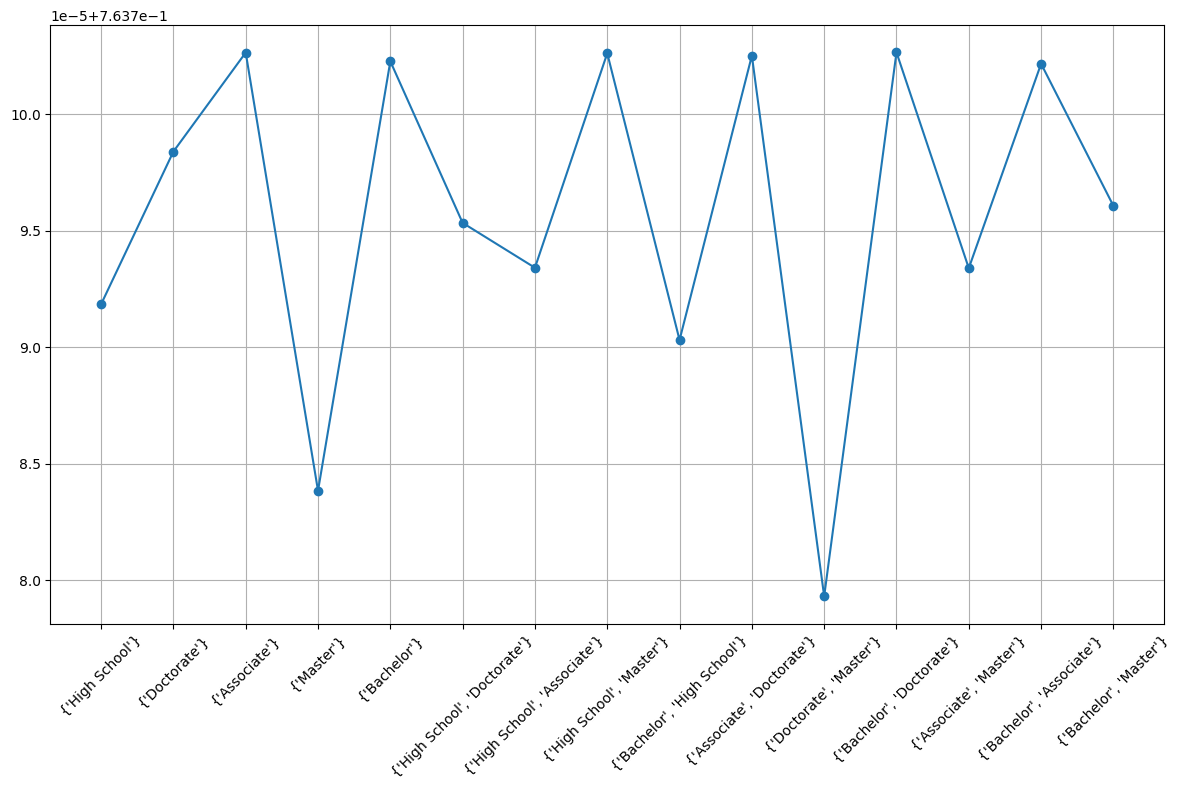

({'Doctorate', 'Master'}, np.float64(0.763779317080313))

Gini Impurity:


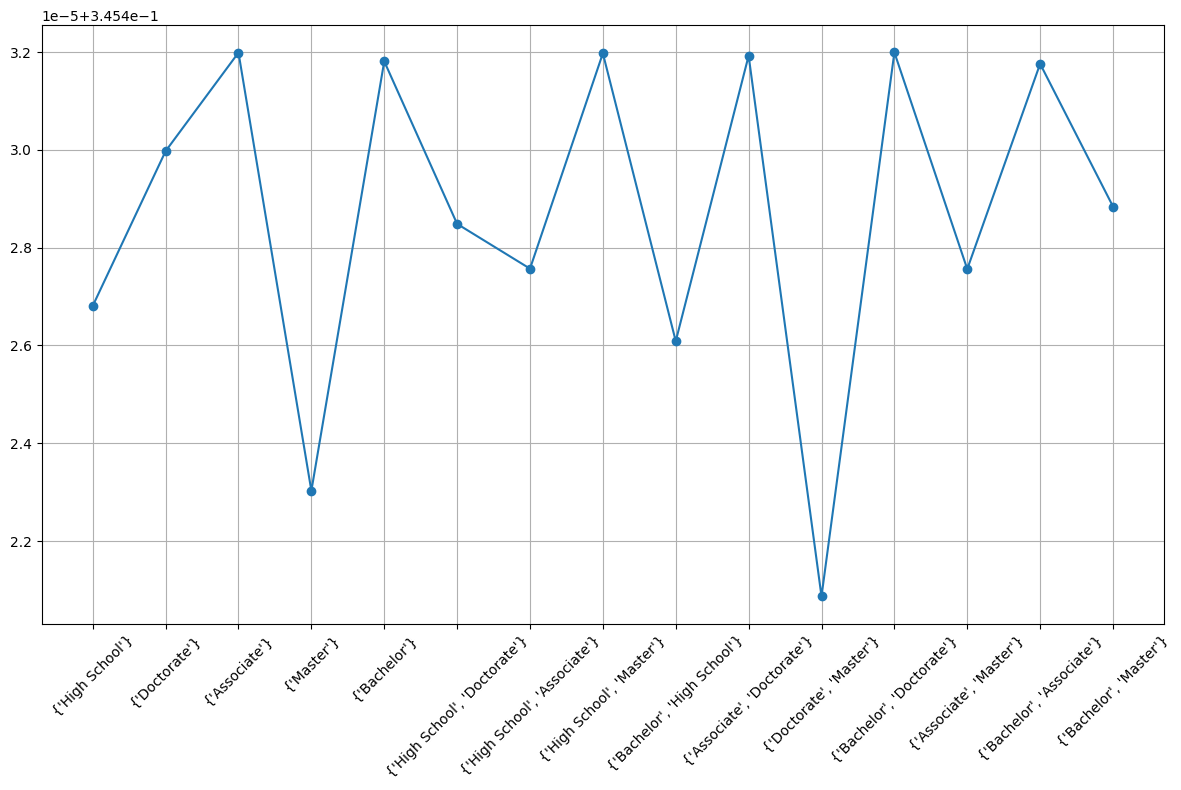

({'Doctorate', 'Master'}, 0.3454208695114436)

In [ ]:
find_best_split(train, "person_education", target_col)

Реализуем собственный класс решающих деревьев. Сделаем это на базе численных метрик

In [ ]:
import numpy as np
from collections import Counter
import math


class MyDecisionTreeClassifier:
    def __init__(self, criterion="gini", max_leaves=None, min_samples_leaf=1):
        self.criterion = criterion
        self.max_leaves = max_leaves
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_leaves = 0

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / m
        return 1 - np.sum(probs**2)

    def _entropy(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / m
        return -np.sum([p * math.log2(p) for p in probs if p > 0])

    def _criterion_func(self, y):
        return self._gini(y) if self.criterion == "gini" else self._entropy(y)

    def _best_split(self, X, y):
        m, n = X.shape
        best_feature, best_threshold, best_gain = None, None, -1
        parent_impurity = self._criterion_func(y)
        for feature in range(n):
            sorted_idx = X[:, feature].argsort()
            X_sorted, y_sorted = X[sorted_idx, feature], y[sorted_idx]
            for i in range(self.min_samples_leaf, m - self.min_samples_leaf):
                if X_sorted[i] == X_sorted[i - 1]:
                    continue
                threshold = (X_sorted[i] + X_sorted[i - 1]) / 2.0
                y_left, y_right = y_sorted[:i], y_sorted[i:]
                if (
                    len(y_left) < self.min_samples_leaf
                    or len(y_right) < self.min_samples_leaf
                ):
                    continue
                impurity_left = self._criterion_func(y_left)
                impurity_right = self._criterion_func(y_right)
                gain = parent_impurity - (
                    len(y_left) / m * impurity_left + len(y_right) / m * impurity_right
                )
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold

    def _build_tree(self, X, y):
        if (
            len(set(y)) == 1
            or len(y) < 2 * self.min_samples_leaf
            or (self.max_leaves and self.n_leaves >= self.max_leaves)
        ):
            self.n_leaves += 1
            return {
                "answer": Counter(y).most_common(1)[0][0],
                "proba": dict(Counter(y)),
            }
        feature, threshold = self._best_split(X, y)
        if feature is None:
            self.n_leaves += 1
            return {
                "answer": Counter(y).most_common(1)[0][0],
                "proba": dict(Counter(y)),
            }
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        left = self._build_tree(X[left_mask], y[left_mask])
        right = self._build_tree(X[right_mask], y[right_mask])
        return {
            "feature": feature,
            "threshold": threshold,
            "left": left,
            "right": right,
        }

    def fit(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        self.n_leaves = 0
        self.root = self._build_tree(X_train, y_train)

    def _predict_one(self, x, node):
        while "answer" not in node:
            if x[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["answer"]

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_proba_one(self, x, node):
        while "answer" not in node:
            if x[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        total = sum(node["proba"].values())
        probs = [0.0, 0.0]
        for k, v in node["proba"].items():
            probs[k] = v / total
        return probs

    def predict_proba(self, X):
        X = np.array(X, dtype=np.float64)
        return np.array([self._predict_proba_one(x, self.root)[0] for x in X])

Преобразуем категориальные данные

In [ ]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category").cat.codes

In [ ]:
train, test = train_test_split(df, test_size=0.3, random_state=42)

In [ ]:
x_cols = train.drop(target_col, axis=1).columns
y_col = target_col

X_train = train[x_cols]
y_train = train[y_col]

X_test = test[x_cols]
y_test = test[y_col]

In [ ]:
X_train.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
30159,38.0,1,0,41579.0,14,3,5750.0,3,11.01,0.14,16.0,647,1
6777,24.0,0,0,28052.0,3,3,7000.0,0,10.62,0.25,3.0,649,0
36563,28.0,0,0,63722.0,4,0,7000.0,1,16.26,0.11,5.0,626,1
11784,26.0,1,0,91870.0,3,0,1200.0,4,10.25,0.01,2.0,662,0
10370,22.0,1,4,29550.0,0,3,10000.0,0,11.01,0.34,3.0,633,0


Обучем нашу и библиотечную модели

In [ ]:
my_dt = MyDecisionTreeClassifier()
my_dt.fit(X_train, y_train)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

Сделаем предсказания

In [ ]:
train_preds = dt.predict(X_train)
test_preds = dt.predict(X_test)
train_probas = dt.predict_proba(X_train)[:, 1]
test_probas = dt.predict_proba(X_test)[:, 1]

my_train_preds = my_dt.predict(X_train)
my_test_preds = my_dt.predict(X_test)
my_train_probas = my_dt.predict_proba(X_train)
my_test_probas = my_dt.predict_proba(X_test)

In [ ]:
my_test_probas

array([1., 1., 0., ..., 1., 1., 1.])

In [ ]:
def show_metrics(true, preds, probas=None):

    print(f"Accuracy: {accuracy_score(true, preds):.2}")
    print(f"Precision: {precision_score(true, preds):.2}")
    print(f"Recall: {recall_score(true, preds):.2}")
    print(f"F1 score: {f1_score(true, preds):.2}")
    print(f"ROC AUC score (predict): {roc_auc_score(true, preds):.2}")

    if probas is not None:
        print(f"ROC AUC score (predict_proba): {roc_auc_score(true, probas):.2}")

    ConfusionMatrixDisplay.from_predictions(true, preds)

Посмотрим на метрики

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0
ROC AUC score (predict): 1.0
ROC AUC score (predict_proba): 1.0


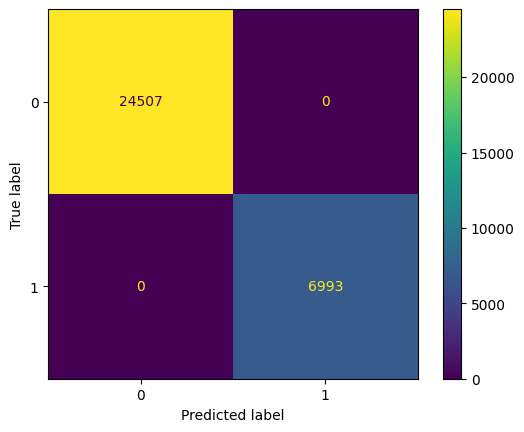

In [ ]:
show_metrics(y_train, train_preds, train_probas)

Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 score: 0.99
ROC AUC score (predict): 0.99
ROC AUC score (predict_proba): 0.00011


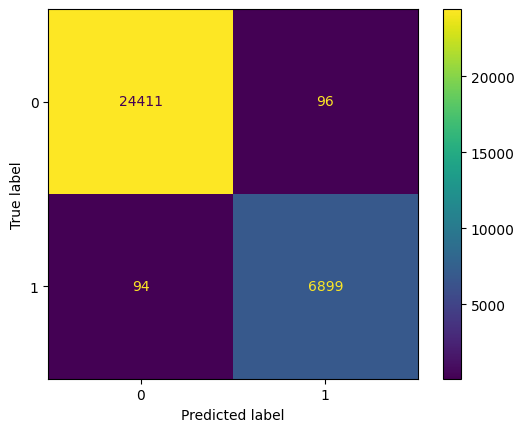

In [ ]:
show_metrics(y_train, my_train_preds, my_train_probas)

Accuracy: 0.9
Precision: 0.77
Recall: 0.77
F1 score: 0.77
ROC AUC score (predict): 0.85
ROC AUC score (predict_proba): 0.85


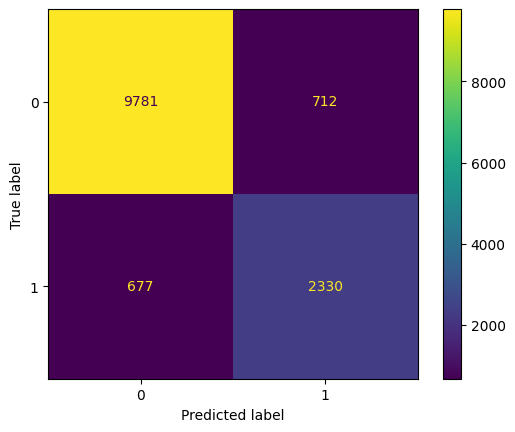

In [ ]:
show_metrics(y_test, test_preds, test_probas)

Accuracy: 0.9
Precision: 0.76
Recall: 0.78
F1 score: 0.77
ROC AUC score (predict): 0.85
ROC AUC score (predict_proba): 0.14


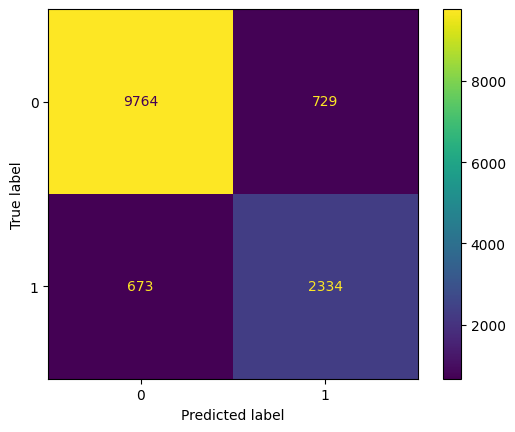

In [ ]:
show_metrics(y_test, my_test_preds, my_test_probas)

Видно, что самописная модель почти не уступает библиотечной.

---
Выберем `entropy`

In [ ]:
my_dt = MyDecisionTreeClassifier(criterion="entropy")
my_dt.fit(X_train, y_train)

In [ ]:
my_ent_train_preds = my_dt.predict(X_train)
my_ent_test_preds = my_dt.predict(X_test)
my_ent_train_probas = my_dt.predict_proba(X_train)
my_ent_test_probas = my_dt.predict_proba(X_test)

Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 score: 0.99
ROC AUC score (predict): 0.99
ROC AUC score (predict_proba): 0.00011


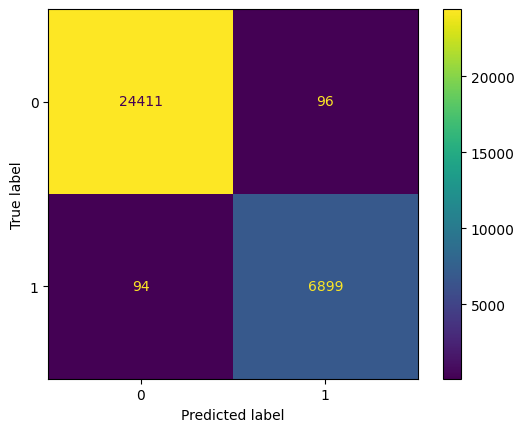

In [ ]:
show_metrics(y_train, my_train_preds, my_train_probas)

Accuracy: 0.9
Precision: 0.76
Recall: 0.78
F1 score: 0.77
ROC AUC score (predict): 0.85
ROC AUC score (predict_proba): 0.14


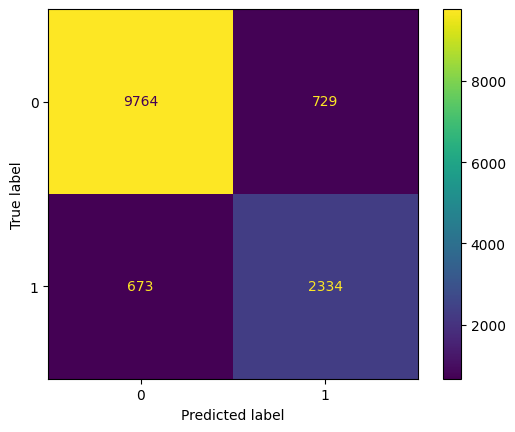

In [ ]:
show_metrics(y_test, my_test_preds, my_test_probas)

Результат не поменялся